# 🚢 Titanic Survival Prediction — Full Machine Learning Pipeline

> **A complete, step-by-step walkthrough of Data Science: from raw data → EDA → Preprocessing → Model Building → Evaluation**

---

## 🗺️ What will we do in this notebook?

| Step | What we do | Why it matters |
|------|-----------|----------------|
| 1 | **Import Libraries** | Load the tools we need |
| 2 | **Load the Data** | Understand what we're working with |
| 3 | **EDA** | Explore patterns and problems in the data |
| 4 | **Preprocessing** | Clean and prepare data for ML models |
| 5 | **Model Building** | Train and compare multiple classifiers |
| 6 | **Evaluation** | Measure how well each model performs |

---

## 📖 About the Titanic Dataset

The Titanic dataset is one of the most famous datasets in Data Science. It contains information about the **891 passengers** aboard the RMS Titanic, which sank on April 15, 1912.

**Our Goal:** Build a model that predicts whether a passenger **survived** or **did not survive**, based on features like their age, gender, and ticket class.

This is a **Binary Classification** problem:
- `Survived = 1` → The passenger survived ✅
- `Survived = 0` → The passenger did not survive ❌

---

### 📊 Column Descriptions

| Column | Description | Type |
|--------|-------------|------|
| `PassengerId` | Unique ID for each passenger | ID (not useful for prediction) |
| `Survived` | **Target variable**: 0 = No, 1 = Yes | Categorical |
| `Pclass` | Ticket class: 1st (rich), 2nd, 3rd (poor) | Ordinal |
| `Name` | Passenger's full name | Text (not directly useful) |
| `Sex` | Gender: male / female | Categorical |
| `Age` | Age in years | Numerical |
| `SibSp` | # of siblings / spouses aboard | Numerical |
| `Parch` | # of parents / children aboard | Numerical |
| `Ticket` | Ticket number | Text (not useful) |
| `Fare` | Ticket price paid | Numerical |
| `Cabin` | Cabin number | Text (lots of missing values) |
| `Embarked` | Port of embarkation: C, Q, or S | Categorical |

---

---
# 📦 Step 1: Import Libraries

**Why do we import libraries?**

Python alone doesn't know how to do Machine Learning. We import **libraries** (collections of pre-written code) that give us powerful tools.

Here's what each library does:

| Library | Purpose |
|---------|--------|
| `pandas` | Load, manipulate, and inspect data (like Excel in Python) |
| `numpy` | Fast numerical computations and arrays |
| `matplotlib` | Create basic plots and charts |
| `seaborn` | Create beautiful statistical visualizations |
| `sklearn` | Machine Learning: preprocessing, models, evaluation |
| `xgboost` | A powerful gradient boosting ML algorithm |

In [111]:
# ── Data manipulation ──────────────────────────────────────────────────────────
import pandas as pd        # DataFrames – our main data structure
import numpy as np         # Numerical operations

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Statistical visualizations (built on matplotlib)

# ── Preprocessing ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# ── Machine Learning Models ────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier       # KNN
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Decision Tree
from sklearn.ensemble import RandomForestClassifier      # Random Forest
from xgboost import XGBClassifier                        # XGBoost

# ── Evaluation ─────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
# 📂 Step 2: Load and Explore the Data

**Why do we start by looking at the data?**

Before doing anything else, we need to **understand what we have**. This helps us:
- See the shape and size of the dataset
- Know which columns are available
- Spot missing values or unexpected data types early

> 💡 **Think of it like a doctor examining a patient before prescribing any treatment.**

In [112]:
# Load the dataset from a CSV file into a pandas DataFrame
# A DataFrame is like a table (rows = passengers, columns = features)

# ⚠️ UPDATE THIS PATH to where your file is located:
df_titanic = pd.read_csv(r"C:\Users\j\Desktop\BrainerX\notebooks\datasets\titanic_dataset\Titanic-Dataset.csv")

print(f"✅ Dataset loaded successfully!")
print(f"   Shape: {df_titanic.shape[0]} rows × {df_titanic.shape[1]} columns")

✅ Dataset loaded successfully!
   Shape: 891 rows × 12 columns


In [113]:
# .head() shows the FIRST 5 rows of the dataset
# This gives us a quick preview of the data — what it looks like
# Always do this first after loading a dataset!

df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
# .columns lists all column names
# Useful to quickly check what features are available

print("Columns in the dataset:")
print(df_titanic.columns.tolist())

Columns in the dataset:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [115]:
# .info() gives us a SUMMARY of the dataset:
#   - Total number of rows
#   - Each column name
#   - How many non-null (non-missing) values exist per column
#   - The data type of each column (int, float, object)

# 🔍 Look carefully: columns with fewer non-null values have MISSING DATA!

df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [116]:
# .shape returns (number_of_rows, number_of_columns)
# We use this to confirm dataset size

rows, cols = df_titanic.shape
print(f"The dataset has {rows} passengers and {cols} features.")

The dataset has 891 passengers and 12 features.


In [117]:
# .describe() computes STATISTICS for all numeric columns:
#   - count: how many non-missing values
#   - mean: average
#   - std: standard deviation (spread of the data)
#   - min/max: smallest and largest values
#   - 25%, 50%, 75%: quartiles (distribution)

# 🔍 Things to notice:
#   - Average age is ~29 years
#   - Fare ranges widely (7 to 512!) — suggests big inequality
#   - Only ~38% survived (Survived mean ≈ 0.38)

df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
# 🔍 Step 3: Exploratory Data Analysis (EDA)

**What is EDA and why do we do it?**

EDA means **visually and statistically exploring** the data to:
- Understand the **distribution** of each feature
- Find **patterns** and **correlations** between features and the target
- Detect **outliers** and **anomalies**
- Make informed decisions about preprocessing

> 💡 **EDA answers the question: "What story does the data tell?"**

---

## 3.1 — Target Variable: Survival Rate

Survival counts:
  Did not survive (0): 549 passengers (61.6%)
  Survived       (1): 342 passengers (38.4%)


C:\Users\j\AppData\Local\Temp\ipykernel_28452\1196074952.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df_titanic, palette=['#e74c3c', '#2ecc71'])


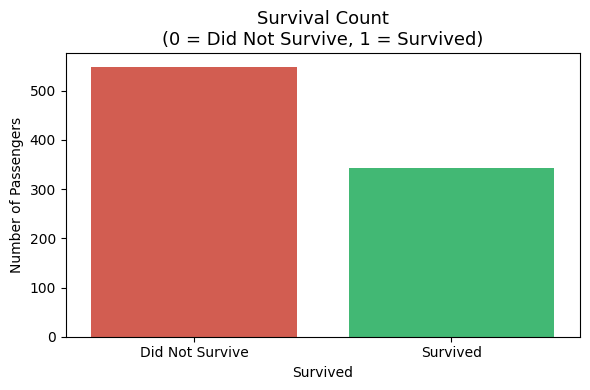

In [118]:
# First, let's check how many passengers survived vs. did not survive
# This is called checking the CLASS BALANCE of our target variable

# Why? If 95% did not survive and only 5% survived,
# a model that always says "did not survive" would be 95% accurate — but useless!

survival_counts = df_titanic['Survived'].value_counts()
print("Survival counts:")
print(f"  Did not survive (0): {survival_counts[0]} passengers ({survival_counts[0]/len(df_titanic)*100:.1f}%)")
print(f"  Survived       (1): {survival_counts[1]} passengers ({survival_counts[1]/len(df_titanic)*100:.1f}%)")

# Visualize with a count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df_titanic, palette=['#e74c3c', '#2ecc71'])
plt.title('Survival Count\n(0 = Did Not Survive, 1 = Survived)', fontsize=13)
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

# ✅ Conclusion: ~62% did not survive, ~38% survived. Slight imbalance but manageable.

## 3.2 — Survival by Gender

**Historical context:** The Titanic followed a "women and children first" evacuation policy. Let's verify this in the data!

      Sex  Survival Rate  Survival Rate %
0  female       0.742038             74.2
1    male       0.188908             18.9


C:\Users\j\AppData\Local\Temp\ipykernel_28452\2453437592.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_titanic,
C:\Users\j\AppData\Local\Temp\ipykernel_28452\2453437592.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_titanic,


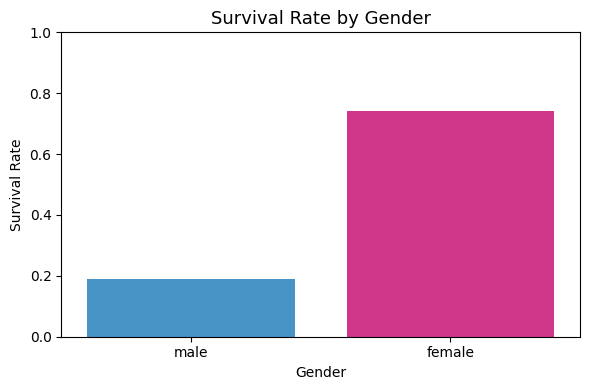

In [119]:
# Let's compare survival rates between male and female passengers
# We group by 'Sex' and calculate the MEAN of 'Survived'
# Mean of 0s and 1s = proportion that survived

survival_by_sex = df_titanic.groupby('Sex')['Survived'].mean().reset_index()
survival_by_sex.columns = ['Sex', 'Survival Rate']
survival_by_sex['Survival Rate %'] = (survival_by_sex['Survival Rate'] * 100).round(1)
print(survival_by_sex)

# Bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df_titanic,
            palette=['#3498db', '#e91e8c'], ci=None)
plt.title('Survival Rate by Gender', fontsize=13)
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ✅ Key Finding:
# ~74% of females survived vs only ~19% of males!
# ➡️ 'Sex' will likely be one of the most important features for our model.

## 3.3 — Survival by Passenger Class (Pclass)

**Hypothesis:** Wealthier passengers (1st class) had better access to lifeboats.

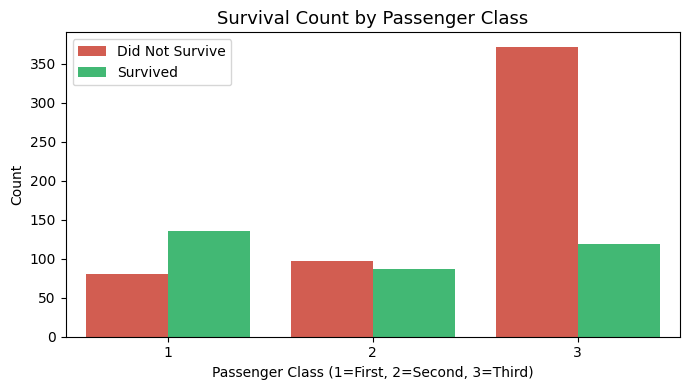


Survival rate by class:
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object


In [120]:
# Pclass = 1 (1st class, rich), 2 (middle), 3 (lower class)
# We expect 1st class to have higher survival rates

plt.figure(figsize=(7, 4))
sns.countplot(x='Pclass', hue='Survived', data=df_titanic,
              palette=['#e74c3c', '#2ecc71'])
plt.title('Survival Count by Passenger Class', fontsize=13)
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

# Survival rate per class
print("\nSurvival rate by class:")
print(df_titanic.groupby('Pclass')['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

# ✅ Key Finding: 1st class ~63% survival, 2nd ~47%, 3rd ~24%
# ➡️ Class was a major factor in survival chances.

## 3.4 — Age Distribution

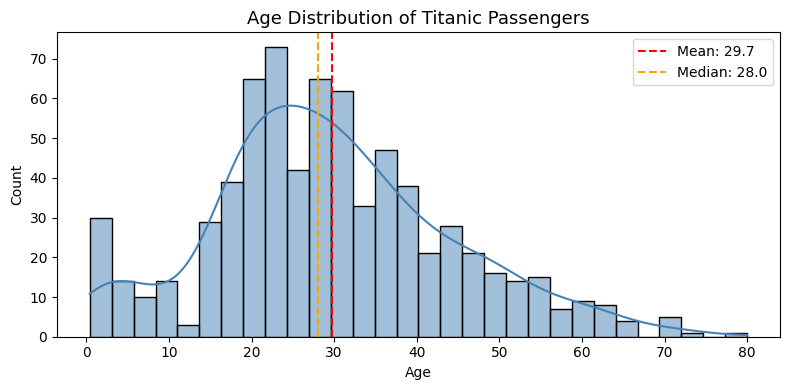

Mean age:   29.70 years
Median age: 28.00 years
Missing:    177 values (19.9%)


In [121]:
# A histogram shows us the DISTRIBUTION of ages
# We want to know: are most passengers young? old? spread evenly?

# Why does this matter?
# - It helps us understand the data we're working with
# - It can reveal if filling missing ages with the MEAN makes sense

plt.figure(figsize=(8, 4))
sns.histplot(df_titanic['Age'].dropna(), bins=30, kde=True, color='steelblue')
plt.axvline(df_titanic['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df_titanic["Age"].mean():.1f}')
plt.axvline(df_titanic['Age'].median(), color='orange', linestyle='--', label=f'Median: {df_titanic["Age"].median():.1f}')
plt.title('Age Distribution of Titanic Passengers', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean age:   {df_titanic['Age'].mean():.2f} years")
print(f"Median age: {df_titanic['Age'].median():.2f} years")
print(f"Missing:    {df_titanic['Age'].isnull().sum()} values ({df_titanic['Age'].isnull().mean()*100:.1f}%)")

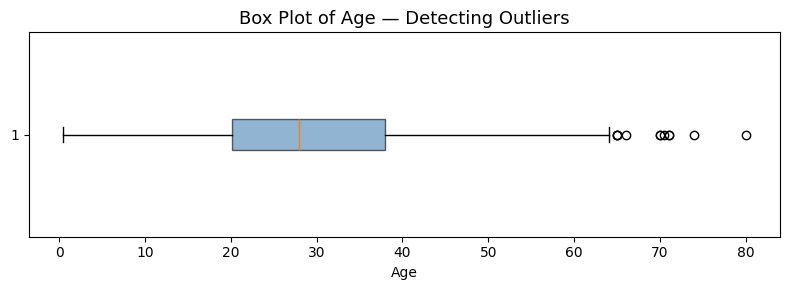

In [122]:
# A BOX PLOT shows the spread of age data and identifies OUTLIERS

# Box plot anatomy:
#   - The box = middle 50% of the data (Q1 to Q3)
#   - The line in the box = median (middle value)
#   - The whiskers = 1.5 × IQR from the box
#   - Dots beyond whiskers = OUTLIERS

plt.figure(figsize=(8, 3))
plt.boxplot(df_titanic['Age'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('Box Plot of Age — Detecting Outliers', fontsize=13)
plt.xlabel('Age')
plt.tight_layout()
plt.show()

# ✅ Observation: Some passengers are very old (80+), but no extreme outliers.
# The age distribution is roughly normal with a slight right skew.

## 3.5 — Fare Distribution

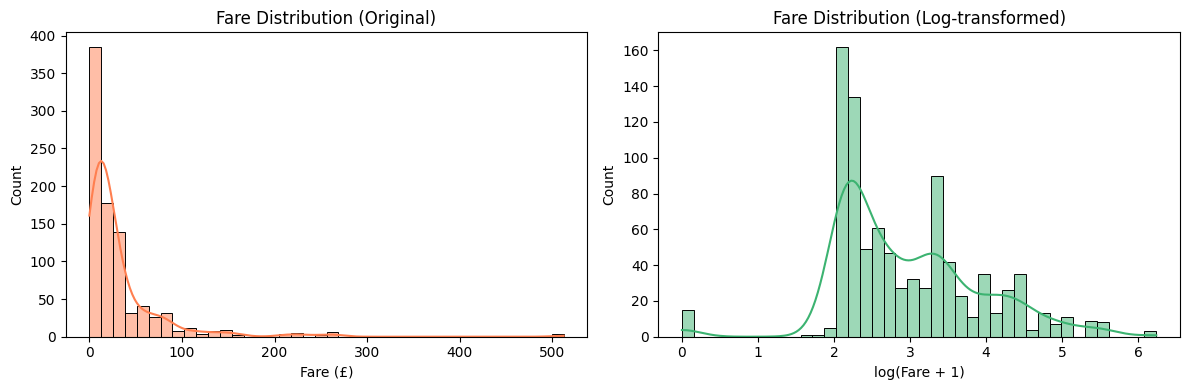

Fare statistics:
  Min:  £0.00
  Max:  £512.33
  Mean: £32.20


In [123]:
# Now let's look at the ticket Fare distribution
# We expect this to be heavily SKEWED (most paid little, a few paid a lot)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Original fare distribution
sns.histplot(df_titanic['Fare'], bins=40, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Fare Distribution (Original)', fontsize=12)
axes[0].set_xlabel('Fare (£)')

# Right: Log-transformed fare — makes skewed data more readable
sns.histplot(np.log1p(df_titanic['Fare']), bins=40, kde=True, color='mediumseagreen', ax=axes[1])
axes[1].set_title('Fare Distribution (Log-transformed)', fontsize=12)
axes[1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.show()

print(f"Fare statistics:")
print(f"  Min:  £{df_titanic['Fare'].min():.2f}")
print(f"  Max:  £{df_titanic['Fare'].max():.2f}")
print(f"  Mean: £{df_titanic['Fare'].mean():.2f}")

# ✅ Observation: Fare is HEAVILY right-skewed.
# Most passengers paid under £50, but a few paid over £500.
# This is called a 'long tail' distribution.

## 3.6 — Missing Values Analysis

**Why do we check for missing values?**

Machine Learning models **cannot handle missing values (NaN)**. Before we can train a model, we must decide what to do with each missing value.

Our options:
1. **Fill with mean/median/mode** (imputation)
2. **Drop the column** (if too many values are missing)
3. **Drop the rows** (rarely, only if a small number of rows are affected)

Columns with missing values:
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


C:\Users\j\AppData\Local\Temp\ipykernel_28452\4050522164.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y='Missing %', data=missing_df, palette='Reds_r')


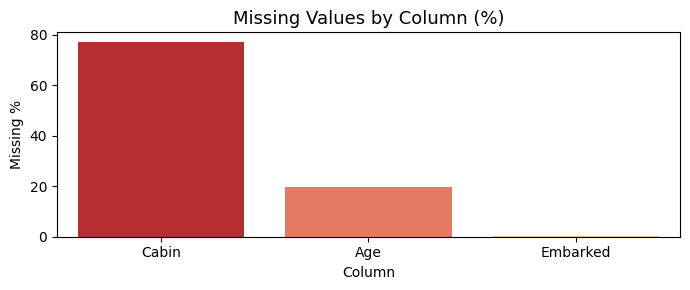

In [124]:
# Calculate how many values are missing for each column
# We show BOTH the count AND the percentage

missing_count = df_titanic.isnull().sum()
missing_percent = df_titanic.isnull().mean() * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:")
print(missing_df)

# Visualize
plt.figure(figsize=(7, 3))
sns.barplot(x=missing_df.index, y='Missing %', data=missing_df, palette='Reds_r')
plt.title('Missing Values by Column (%)', fontsize=13)
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

# ✅ Summary:
# Cabin: 77% missing → TOO MUCH to fill, we will DROP this column
# Age:   20% missing → We will fill with the MEDIAN age
# Embarked: 0.2% missing → We will fill with the MODE (most common value)

## 3.7 — Correlation Analysis

**What is correlation?**

Correlation measures the **linear relationship** between two variables:
- `+1` → Perfect positive relationship (as one goes up, the other goes up)
- `-1` → Perfect negative relationship (as one goes up, the other goes down)
- `0` → No linear relationship

A **heatmap** visualizes correlations between all numeric columns at once.

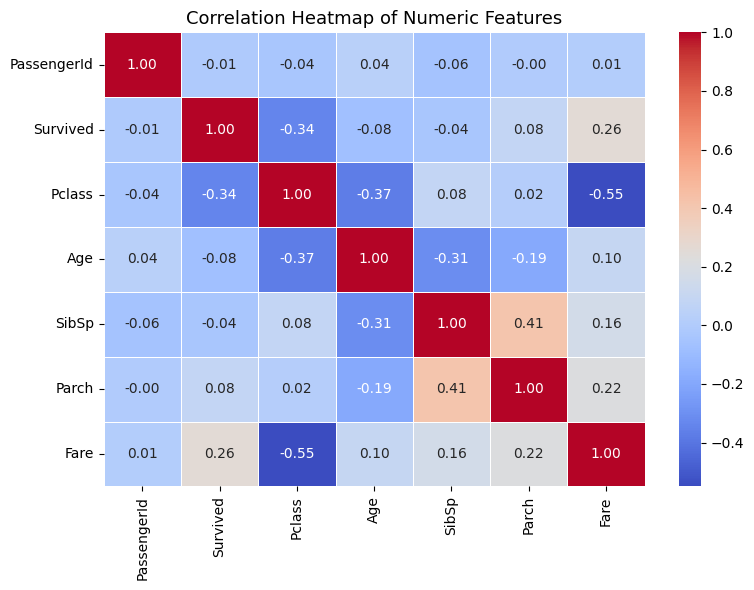


Correlation with 'Survived':
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64


In [125]:
# Compute the correlation matrix for all numeric columns
# We're especially interested in how each feature correlates with 'Survived'

numeric_cols = df_titanic.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,           # Show the correlation values inside the cells
    fmt='.2f',            # Round to 2 decimal places
    cmap='coolwarm',      # Blue = negative, Red = positive correlation
    linewidths=0.5,
    linecolor='white'
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

# 🔍 What to look for in the 'Survived' row/column:
# - Pclass has a NEGATIVE correlation with Survived (-0.34)
#   → Higher class number (3rd class) → lower survival
# - Fare has a POSITIVE correlation (+0.26)
#   → Higher fare → higher survival (richer passengers)

print("\nCorrelation with 'Survived':")
print(correlation_matrix['Survived'].sort_values(ascending=False))

---
# 🧹 Step 4: Data Preprocessing

**What is preprocessing and why is it so important?**

Raw data is almost never ready for a machine learning model. We need to:

1. **Handle missing values** — models break with NaN values
2. **Drop useless columns** — garbage in = garbage out
3. **Encode categorical variables** — models work with numbers, not text
4. **Scale numerical features** — keeps features on equal footing
5. **Split into train/test sets** — evaluate on unseen data

> 💡 **Good preprocessing = better model performance. This step is often more important than which model you choose!**

---

## 4.1 — Handle Missing Values

In [126]:
# ── 4.1a: Drop the 'Cabin' column ────────────────────────────────────────────
# Reason: 77% of values are missing!
# It's too risky to fill in such a large proportion — we'd be making up most of the data.
# Better to drop it entirely.

df_titanic.drop(columns=['Cabin'], inplace=True)

print("✅ Dropped 'Cabin' column (77% missing)")
print(f"   Remaining columns: {df_titanic.shape[1]}")

✅ Dropped 'Cabin' column (77% missing)
   Remaining columns: 11


In [127]:
# ── 4.1b: Fill missing 'Age' with MEDIAN ─────────────────────────────────────
# Reason: Age is skewed (some very old passengers), so MEDIAN is more robust than mean.
# The median is the middle value — it's not affected by extreme outliers.

# Why not mean?
# If there are outliers (very old passengers), the mean gets pulled up,
# and we'd be filling missing ages with an unrealistic value.

age_median = df_titanic['Age'].median()
df_titanic['Age'].fillna(age_median, inplace=True)

print(f"✅ Filled missing 'Age' values with median = {age_median}")
print(f"   Missing 'Age' values now: {df_titanic['Age'].isnull().sum()}")

✅ Filled missing 'Age' values with median = 28.0
   Missing 'Age' values now: 0


In [128]:
# ── 4.1c: Fill missing 'Embarked' with MODE ───────────────────────────────────
# Reason: Only 2 values are missing in 'Embarked'.
# For categorical columns, the MODE (most frequent value) is the best fill.
# The most common port of departure was 'S' (Southampton).

embarked_mode = df_titanic['Embarked'].mode()[0]  # mode() returns a Series; [0] = first element
df_titanic['Embarked'].fillna(embarked_mode, inplace=True)

print(f"✅ Filled missing 'Embarked' values with mode = '{embarked_mode}'")
print(f"   Missing 'Embarked' values now: {df_titanic['Embarked'].isnull().sum()}")

# Verify: no more missing values
total_missing = df_titanic.isnull().sum().sum()
print(f"\n✅ Total missing values remaining: {total_missing}")

✅ Filled missing 'Embarked' values with mode = 'S'
   Missing 'Embarked' values now: 0

✅ Total missing values remaining: 0


## 4.2 — Drop Irrelevant Columns

**Why drop columns?**

Some columns contain **no useful information** for prediction:
- `PassengerId` — just an arbitrary number, carries no signal
- `Name` — passenger names don't predict survival
- `Ticket` — ticket numbers are random strings with no pattern

Keeping them would add **noise** without adding any signal.

In [129]:
# Drop columns that don't help predict survival
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
df_titanic.drop(columns=columns_to_drop, inplace=True)

print(f"✅ Dropped irrelevant columns: {columns_to_drop}")
print(f"   Remaining columns ({df_titanic.shape[1]}):")
print(f"   {df_titanic.columns.tolist()}")

✅ Dropped irrelevant columns: ['PassengerId', 'Name', 'Ticket']
   Remaining columns (8):
   ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 4.3 — Encode Categorical Variables

**Why do we need to encode categories?**

Machine Learning models are **mathematical** — they work with **numbers only**.
We cannot pass `"male"` or `"female"` directly. We must convert them to numbers.

**Two main techniques:**

| Technique | When to use | Example |
|-----------|------------|--------|
| **Label Encoding** | Ordered/binary categories | male=0, female=1 |
| **One-Hot Encoding** | Unordered categories with 3+ values | Embarked → C, Q, S → separate columns |

In [130]:
# ── 4.3a: Encode 'Sex' using Label Encoding ───────────────────────────────────
# Sex has only 2 values: 'male' and 'female'
# We can simply map: female → 0, male → 1
#
# Why label encoding here?
# Because there are only 2 values, one-hot encoding would create redundant columns.
# (If female=0 and male=1, we only need 1 column.)

df_titanic['Sex'] = df_titanic['Sex'].map({'female': 0, 'male': 1})

print("✅ Encoded 'Sex' column: female=0, male=1")
print(df_titanic['Sex'].value_counts())

✅ Encoded 'Sex' column: female=0, male=1
1    577
0    314
Name: Sex, dtype: int64


In [131]:
# ── 4.3b: Encode 'Embarked' using One-Hot Encoding ───────────────────────────
# Embarked has 3 values: 'S', 'C', 'Q'
# These are NOT ordered — 'S' is not greater than 'C'.
# One-Hot Encoding creates a SEPARATE BINARY COLUMN for each category.

# pd.get_dummies() does one-hot encoding automatically:
#   drop_first=True removes one column to avoid the 'dummy variable trap'
#   (We don't need 3 columns if 2 give all the info)

df_encoded = pd.get_dummies(df_titanic, columns=['Embarked'], drop_first=True)

print("✅ One-Hot Encoded 'Embarked' column.")
print(f"   New columns: {[c for c in df_encoded.columns if 'Embarked' in c]}")
print(f"   Total columns now: {df_encoded.shape[1]}")
df_encoded.head()

✅ One-Hot Encoded 'Embarked' column.
   New columns: ['Embarked_Q', 'Embarked_S']
   Total columns now: 9


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


## 4.4 — Feature Selection: Choosing What to Give the Model

**What is Feature Selection?**

After cleaning and encoding our data, we now have **9 columns** in `df_encoded`.
But not all columns are equally useful for predicting survival.

**Feature Selection** = deciding which columns (features) to include as inputs to our model.

We need to define two things:
- **`X`** → the **features** (inputs) — everything the model uses to make a prediction
- **`y`** → the **target** (output) — what we want the model to predict (`Survived`)

> 💡 Think of it like this:
> - `X` = the exam questions
> - `y` = the correct answers
> - The model learns how to go from questions → answers

---

### 🔍 Which features should we keep?

Here's a quick look at what each remaining column contains:

| Column | Keep? | Reason |
|--------|-------|--------|
| `Survived` | ❌ (this IS our target `y`) | We are trying to predict this |
| `Pclass` | ✅ | Ticket class — strongly related to survival |
| `Sex` | ✅ | Gender — strongest predictor (women first) |
| `Age` | ✅ | Age matters (children had priority) |
| `SibSp` | ✅ | Number of siblings/spouses aboard |
| `Parch` | ✅ | Number of parents/children aboard |
| `Fare` | ✅ | Ticket price — reflects wealth |
| `Embarked_Q` | ✅ | Encoded port (Queenstown = 1, else = 0) |
| `Embarked_S` | ✅ | Encoded port (Southampton = 1, else = 0) |


In [132]:
# First, let's see what our encoded dataframe looks like right now
# This helps us decide which columns to use

print("All columns in df_encoded:")
print(df_encoded.columns.tolist())
print()
print("Shape:", df_encoded.shape)
print()
print("First 3 rows preview:")
df_encoded.head(3)

All columns in df_encoded:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Shape: (891, 9)

First 3 rows preview:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1


In [133]:
# ── Define X (features) and y (target) ─────────────────────────────────────
#
# X = the INPUT columns — what we give to the model to learn from
#     We include everything EXCEPT 'Survived' (that's what we're predicting)
#
# y = the TARGET column — what the model has to predict
#     This is the 'Survived' column: 0 = did not survive, 1 = survived

# X gets all columns EXCEPT 'Survived'
X = df_encoded.drop(columns=['Survived'])

# y gets ONLY the 'Survived' column
y = df_encoded['Survived']

# Let's verify what we have
print("✅ Features (X) — these are the model's INPUTS:")
print(f"   Columns: {X.columns.tolist()}")
print(f"   Shape:   {X.shape}  → {X.shape[0]} rows, {X.shape[1]} features")
print()
print("✅ Target (y) — this is what the model will PREDICT:")
print(f"   Name:    Survived")
print(f"   Shape:   {y.shape}  → {y.shape[0]} values")
print()
print("Distribution of the target:")
print(y.value_counts().rename({0: 'Did Not Survive (0)', 1: 'Survived (1)'}))

✅ Features (X) — these are the model's INPUTS:
   Columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
   Shape:   (891, 8)  → 891 rows, 8 features

✅ Target (y) — this is what the model will PREDICT:
   Name:    Survived
   Shape:   (891,)  → 891 values

Distribution of the target:
Did Not Survive (0)    549
Survived (1)           342
Name: Survived, dtype: int64


---
## 4.5 — Train / Test Split

**Why do we split the data into two parts?**

Imagine a student who memorizes all the answers to practice questions.
On exam day, when they see **new** questions they've never seen, they fail.

The same problem happens with ML models — if we train AND test on the same data,
the model might just **memorize** the answers instead of learning real patterns.
This is called **overfitting**.

**The solution:** Split the data into two separate sets:

```
Full Dataset (891 passengers)
         ↓
┌─────────────────────┬────────────────┐
│   Training Set      │   Test Set     │
│   75% → 668 rows    │  25% → 223 rows│
│                     │                │
│  Model LEARNS here  │ Model TESTED   │
│                     │ on NEW data    │
└─────────────────────┴────────────────┘
```

**Key parameters we use:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `test_size=0.25` | 25% | 25% of data becomes the test set |
| `random_state=42` | 42 | Seed for reproducibility — same split every time |
| `stratify=y` | y | Ensures both sets have the same % of survivors |

> ⚠️ **Important:** `stratify=y` makes sure the split is **balanced**.
> Without it, we might accidentally put most survivors in one set and ruin the results.


In [134]:
# train_test_split() splits X and y at the SAME TIME
# It shuffles the data first, then cuts it into 2 pieces
#
# It returns 4 things:
#   X_train → the feature rows used for TRAINING  (75%)
#   X_test  → the feature rows used for TESTING   (25%)
#   y_train → the target values for training      (75%)
#   y_test  → the target values for testing       (25%)

X_train, X_test, y_train, y_test = train_test_split(
    X,              # our features
    y,              # our target
    test_size=0.25, # 25% goes to test, 75% stays for training
    random_state=42,# makes the split reproducible (same result every run)
    stratify=y      # keeps the same ratio of 0s and 1s in both sets
)

# Let's verify the sizes
print("✅ Data split complete!")
print()
print(f"   Training set:  X_train = {X_train.shape}  |  y_train = {y_train.shape}")
print(f"   Test set:      X_test  = {X_test.shape}   |  y_test  = {y_test.shape}")
print()
print("Survival ratio check (should be ~38% in both):")
print(f"   Training set: {y_train.mean()*100:.1f}% survived")
print(f"   Test set:     {y_test.mean()*100:.1f}% survived")
print("   ✅ stratify=y worked — both sets have the same survival rate!")

✅ Data split complete!

   Training set:  X_train = (668, 8)  |  y_train = (668,)
   Test set:      X_test  = (223, 8)   |  y_test  = (223,)

Survival ratio check (should be ~38% in both):
   Training set: 38.3% survived
   Test set:     38.6% survived
   ✅ stratify=y worked — both sets have the same survival rate!


---
## 4.6 — Feature Scaling

**Why do we need to scale the features?**

Look at the range of values in our features:

| Feature | Minimum | Maximum | Range |
|---------|---------|---------|-------|
| `Age` | 0 | 80 | 80 |
| `Fare` | 0 | 512 | 512 |
| `Pclass` | 1 | 3 | 2 |
| `Sex` | 0 | 1 | 1 |

Some features have **very large values** (like Fare = 512) and some have **very small values** (like Sex = 0 or 1).

For models like **KNN**, this is a big problem!
KNN calculates the **distance** between passengers to find neighbors.
If Fare ranges up to 512 and Sex only goes from 0 to 1,
then **Fare will dominate the distance** — the model will basically ignore Sex, Age, etc.

**The fix: StandardScaler**

`StandardScaler` transforms every feature so that:
- **Mean = 0** (centered around zero)
- **Standard Deviation = 1** (spread is normalized)

Formula: `z = (value - mean) / standard_deviation`

**🚨 Critical Rule — No Data Leakage!**

We must:
1. **`fit_transform(X_train)`** → the scaler *learns* the mean/std from training data, then applies it
2. **`transform(X_test)`** → the scaler *only applies* the learned mean/std (does NOT re-learn)

Why? Because the test set is supposed to represent **unseen future data**.
If we let the scaler peek at test data, we're cheating — the model's score will be unrealistically high.


In [135]:
# StandardScaler works in two steps:
#   Step 1: .fit()          → learns the mean and std from the data
#   Step 2: .transform()    → applies the scaling formula: z = (x - mean) / std
#
# .fit_transform() does BOTH steps at once (only for training data!)
# .transform()     does ONLY step 2    (for test data — no learning allowed!)

scaler = StandardScaler()  # create the scaler object

# ── Apply to TRAINING data ─────────────────────────────────────────────────
# fit_transform = LEARN the mean/std from X_train, then SCALE X_train
X_train_scaled = scaler.fit_transform(X_train)

# ── Apply to TEST data ─────────────────────────────────────────────────────
# transform = use the SAME mean/std learned from training, just SCALE X_test
# We do NOT call fit() again on test data!
X_test_scaled = scaler.transform(X_test)

# Let's verify: after scaling, each feature should have mean ≈ 0 and std ≈ 1
import pandas as pd
scaled_check = pd.DataFrame(X_train_scaled, columns=X.columns)

print("✅ Scaling complete!")
print()
print("Before scaling — original ranges:")
print(f"   Age  → min: {X_train['Age'].min():.1f},  max: {X_train['Age'].max():.1f},  mean: {X_train['Age'].mean():.1f}")
print(f"   Fare → min: {X_train['Fare'].min():.1f}, max: {X_train['Fare'].max():.1f}, mean: {X_train['Fare'].mean():.1f}")
print()
print("After scaling — all features are now on the same scale:")
print(f"   Age  → min: {scaled_check['Age'].min():.2f},  max: {scaled_check['Age'].max():.2f},  mean: {scaled_check['Age'].mean():.4f}")
print(f"   Fare → min: {scaled_check['Fare'].min():.2f}, max: {scaled_check['Fare'].max():.2f}, mean: {scaled_check['Fare'].mean():.4f}")
print()
print("✅ Notice: all features now have mean ≈ 0 — fair competition between features!")

✅ Scaling complete!

Before scaling — original ranges:
   Age  → min: 0.4,  max: 80.0,  mean: 29.6
   Fare → min: 0.0, max: 512.3, mean: 31.2

After scaling — all features are now on the same scale:
   Age  → min: -2.25,  max: 3.89,  mean: 0.0000
   Fare → min: -0.66, max: 10.15, mean: 0.0000

✅ Notice: all features now have mean ≈ 0 — fair competition between features!


---
# 🤖 Step 5: Model Building & Training

**We are ready to train our machine learning models!**

At this point, we have:
- ✅ Cleaned and preprocessed data
- ✅ Defined our features `X` and target `y`
- ✅ Split into training and test sets
- ✅ Scaled our features

Now we will train **4 different models** and compare them:

| # | Model | Key Idea |
|---|-------|----------|
| 1 | **KNN** | Find the K most similar passengers and vote |
| 2 | **Decision Tree** | Ask yes/no questions until a decision is reached |
| 3 | **Random Forest** | Build many trees and take the majority vote |
| 4 | **XGBoost** | Build trees one by one, each fixing previous errors |

---

### 📊 Understanding Evaluation Metrics

Before we start, let's understand how we measure a model's performance.

When a model makes predictions, there are **4 possible outcomes**:

```
                    PREDICTED: No   PREDICTED: Yes
ACTUAL: No      →    TN ✅              FP ❌
ACTUAL: Yes     →    FN ❌              TP ✅
```

- **TN (True Negative):** Model said "no" and was right ✅
- **TP (True Positive):** Model said "yes" and was right ✅
- **FP (False Positive):** Model said "yes" but was wrong ❌ (false alarm)
- **FN (False Negative):** Model said "no" but was wrong ❌ (missed a survivor)

From these, we calculate:

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | What % of ALL predictions were correct? |
| **Precision** | TP / (TP + FP) | Of predicted survivors, how many actually survived? |
| **Recall** | TP / (TP + FN) | Of actual survivors, how many did we catch? |
| **F1-Score** | 2 × P × R / (P+R) | Balance between Precision and Recall |

> 💡 **F1-Score** is the most important metric when classes are slightly imbalanced (like here: 62% didn't survive, 38% did).


---
## 5.1 — Model 1: K-Nearest Neighbors (KNN)

**How does KNN work?**

KNN is one of the simplest and most intuitive ML algorithms.
Here's the idea in plain English:

> *"To decide if a new passenger survived, I look at the 5 most similar passengers in the training data.
> If most of them survived, I predict this one survived too."*

**Step by step:**
1. A new passenger comes in (from the test set)
2. Calculate the distance to **every** passenger in the training set
3. Find the **K=5 nearest** passengers (most similar)
4. Count how many of those 5 survived
5. Majority vote → that's the prediction

**Why does KNN need scaled data?**

Because KNN uses **distance** (like Euclidean distance) to find neighbors.
If Age goes from 0-80 and Fare goes from 0-512, Fare would dominate the distance.
Scaling fixes this so all features contribute equally.

> ⚠️ **KNN uses `X_train_scaled` and `X_test_scaled`** — the scaled versions!


In [136]:
# ── Create the KNN model ──────────────────────────────────────────────────────
# n_neighbors=5 means: look at the 5 nearest passengers and take majority vote
# This is called K=5 (K is the number of neighbors)

knn = KNeighborsClassifier(n_neighbors=5)
# At this point, the model is just a blank template — it hasn't learned anything yet

# ── Train the model ───────────────────────────────────────────────────────────
# .fit() is the training step
# We give it X_train_scaled (features) and y_train (correct answers)
# KNN doesn't build a formula — it just STORES all training data
# When a new passenger comes, it searches through the stored data to find neighbors

knn.fit(X_train_scaled, y_train)
# X_train_scaled → the scaled feature values of 668 training passengers
# y_train        → whether each of those 668 passengers survived or not

# ── Make predictions ──────────────────────────────────────────────────────────
# .predict() applies the trained model to the TEST set
# For each test passenger, KNN finds their 5 nearest training neighbors and votes
# ⚠️ We use X_test_scaled (not X_test) because we scaled our data!

y_pred_knn = knn.predict(X_test_scaled)
# y_pred_knn now contains 223 predictions: 0 or 1 for each test passenger

print("✅ KNN model trained!")
print(f"   Training samples used: {X_train_scaled.shape[0]}")
print(f"   Test predictions made: {len(y_pred_knn)}")
print(f"   Predicted survivors:   {y_pred_knn.sum()} out of {len(y_pred_knn)}")

✅ KNN model trained!
   Training samples used: 668
   Test predictions made: 223
   Predicted survivors:   76 out of 223


### 📊 Evaluating KNN

Now let's see how well KNN performed on the **test set** (unseen data).

The `classification_report` gives us:
- **precision** — out of all passengers predicted to survive, how many actually did?
- **recall** — out of all actual survivors, how many did we correctly identify?
- **f1-score** — balance between precision and recall (the most important metric)
- **support** — how many passengers are in each class in the test set


     🤖 KNN (K=5) — Classification Report
                 precision    recall  f1-score   support

Did Not Survive     0.8095    0.8686    0.8380       137
       Survived     0.7632    0.6744    0.7160        86

       accuracy                         0.7937       223
      macro avg     0.7863    0.7715    0.7770       223
   weighted avg     0.7916    0.7937    0.7910       223



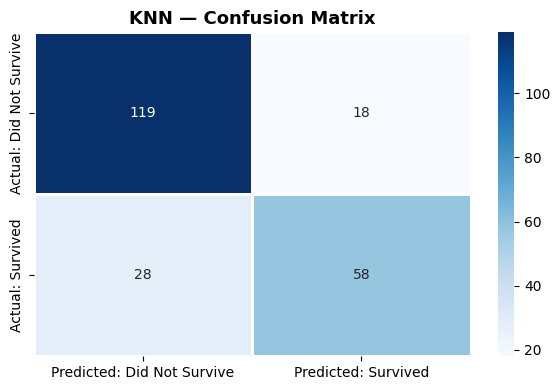

✅ True Negatives  (TN): 119  — correctly predicted 'Did Not Survive'
❌ False Positives (FP): 18  — predicted 'Survived' but actually didn't
❌ False Negatives (FN): 28  — predicted 'Did Not Survive' but actually survived
✅ True Positives  (TP): 58  — correctly predicted 'Survived'


In [137]:
# ── Print the Classification Report ─────────────────────────────────────────
# This gives us a full breakdown of how the model performed on the TEST set
# We compare y_test (true labels) vs y_pred_knn (predicted labels)

from sklearn.metrics import classification_report, confusion_matrix

print("=" * 55)
print("     🤖 KNN (K=5) — Classification Report")
print("=" * 55)

print(classification_report(
    y_test,          # the REAL answers (ground truth)
    y_pred_knn,      # the model's PREDICTIONS
    target_names=['Did Not Survive', 'Survived'],  # human-readable class names
    digits=4         # show 4 decimal places for precision
))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
# A confusion matrix shows us exactly WHERE the model made mistakes
# Rows = actual labels, Columns = predicted labels

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_knn,
    annot=True,        # show the numbers inside each cell
    fmt='d',           # format as integers (not scientific notation)
    cmap='Blues',      # blue color scheme
    xticklabels=['Predicted: Did Not Survive', 'Predicted: Survived'],
    yticklabels=['Actual: Did Not Survive', 'Actual: Survived'],
    linewidths=1,
    linecolor='white'
)
plt.title('KNN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Reading the confusion matrix ─────────────────────────────────────────────
tn, fp, fn, tp = cm_knn.ravel()  # ravel() flattens the 2x2 matrix into 4 values
print(f"✅ True Negatives  (TN): {tn}  — correctly predicted 'Did Not Survive'")
print(f"❌ False Positives (FP): {fp}  — predicted 'Survived' but actually didn't")
print(f"❌ False Negatives (FN): {fn}  — predicted 'Did Not Survive' but actually survived")
print(f"✅ True Positives  (TP): {tp}  — correctly predicted 'Survived'")

---
## 5.2 — Model 2: Decision Tree

**How does a Decision Tree work?**

A Decision Tree learns a series of **yes/no questions** about the data.
It's like a flowchart that leads to a final decision.

**Example of what the tree might learn:**

```
         Is the passenger female?
              /           \
           YES              NO
            |                |
    Is Pclass 1 or 2?    Is Age < 10?
         /    \              /    \
       YES     NO          YES    NO
        |       |           |      |
    SURVIVED  DIED      SURVIVED  DIED
```

**Important parameters we set:**

| Parameter | Value | Why |
|-----------|-------|-----|
| `max_depth=4` | 4 levels deep | Prevents the tree from memorizing every detail (overfitting) |
| `min_samples_leaf=10` | min 10 passengers per leaf | Prevents tiny, unreliable leaf nodes |
| `random_state=42` | 42 | Reproducibility |

**Decision Trees do NOT need scaled data** — they split on thresholds, not distances.

> 💡 One big advantage of Decision Trees: they are **fully interpretable** —
> you can literally draw the tree and understand every decision it makes!


In [138]:
# ── Create the Decision Tree model ───────────────────────────────────────────

dt = DecisionTreeClassifier(
    max_depth=4,          # maximum 4 levels of questions
    # without max_depth, the tree grows until it memorizes every training passenger
    # (overfitting!) — limiting depth forces the tree to learn general patterns

    min_samples_leaf=10,  # each leaf must have at least 10 passengers
    # this prevents the tree from making decisions based on very few examples
    # (those would be unreliable rules)

    random_state=42       # ensures the same tree is built every run
)

# ── Train the model ───────────────────────────────────────────────────────────
# .fit() builds the tree by finding the best questions at each node
# The algorithm tries all possible splits and picks the one that best
# separates survivors from non-survivors (using Gini impurity)
#
# ⚠️ Decision Trees work on ORIGINAL data — no scaling needed!
# They split on value thresholds, not distances

dt.fit(X_train, y_train)
# X_train  → unscaled features (Decision Trees don't need scaling)
# y_train  → the correct survival labels

# ── Make predictions ──────────────────────────────────────────────────────────
y_pred_dt = dt.predict(X_test)
# For each test passenger, the tree follows the learned questions
# until it reaches a leaf node, then outputs the majority class

print("✅ Decision Tree trained!")
print(f"   Tree depth reached: {dt.get_depth()} (max allowed: 4)")
print(f"   Number of leaf nodes: {dt.get_n_leaves()}")
print(f"   Features used: {X_train.columns.tolist()}")

✅ Decision Tree trained!
   Tree depth reached: 4 (max allowed: 4)
   Number of leaf nodes: 13
   Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


  🌳 Decision Tree — Classification Report
                 precision    recall  f1-score   support

Did Not Survive     0.7545    0.9197    0.8289       137
       Survived     0.8036    0.5233    0.6338        86

       accuracy                         0.7668       223
      macro avg     0.7790    0.7215    0.7314       223
   weighted avg     0.7734    0.7668    0.7537       223



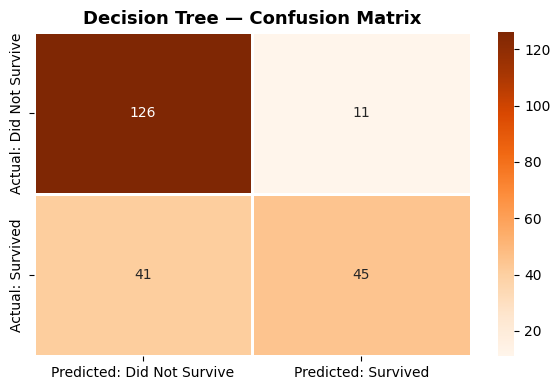

✅ True Negatives  (TN): 126
❌ False Positives (FP): 11
❌ False Negatives (FN): 41
✅ True Positives  (TP): 45


In [ ]:
# ── Print the Classification Report ─────────────────────────────────────────

print("=" * 55)
print("   Decision Tree — Classification Report")
print("=" * 55)

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=['Did Not Survive', 'Survived'],
    digits=4
))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Predicted: Did Not Survive', 'Predicted: Survived'],
    yticklabels=['Actual: Did Not Survive', 'Actual: Survived'],
    linewidths=1,
    linecolor='white'
)
plt.title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_dt.ravel()
print(f"✅ True Negatives  (TN): {tn}")
print(f"❌ False Positives (FP): {fp}")
print(f"❌ False Negatives (FN): {fn}")
print(f"✅ True Positives  (TP): {tp}")

### 🌳 Visualizing the Decision Tree

One of the best things about Decision Trees is that you can **see the actual rules** the model learned.

How to read each box (node):
- **The question at the top** — what the tree is asking (e.g., `Sex <= 0.5` means "is the passenger female?")
- **gini** — how mixed the passengers are in this node (0.0 = perfectly pure, all one class)
- **samples** — how many training passengers reached this node
- **value** — `[not_survived, survived]` counts in this node
- **class** — the majority class (what the tree would predict if it stopped here)


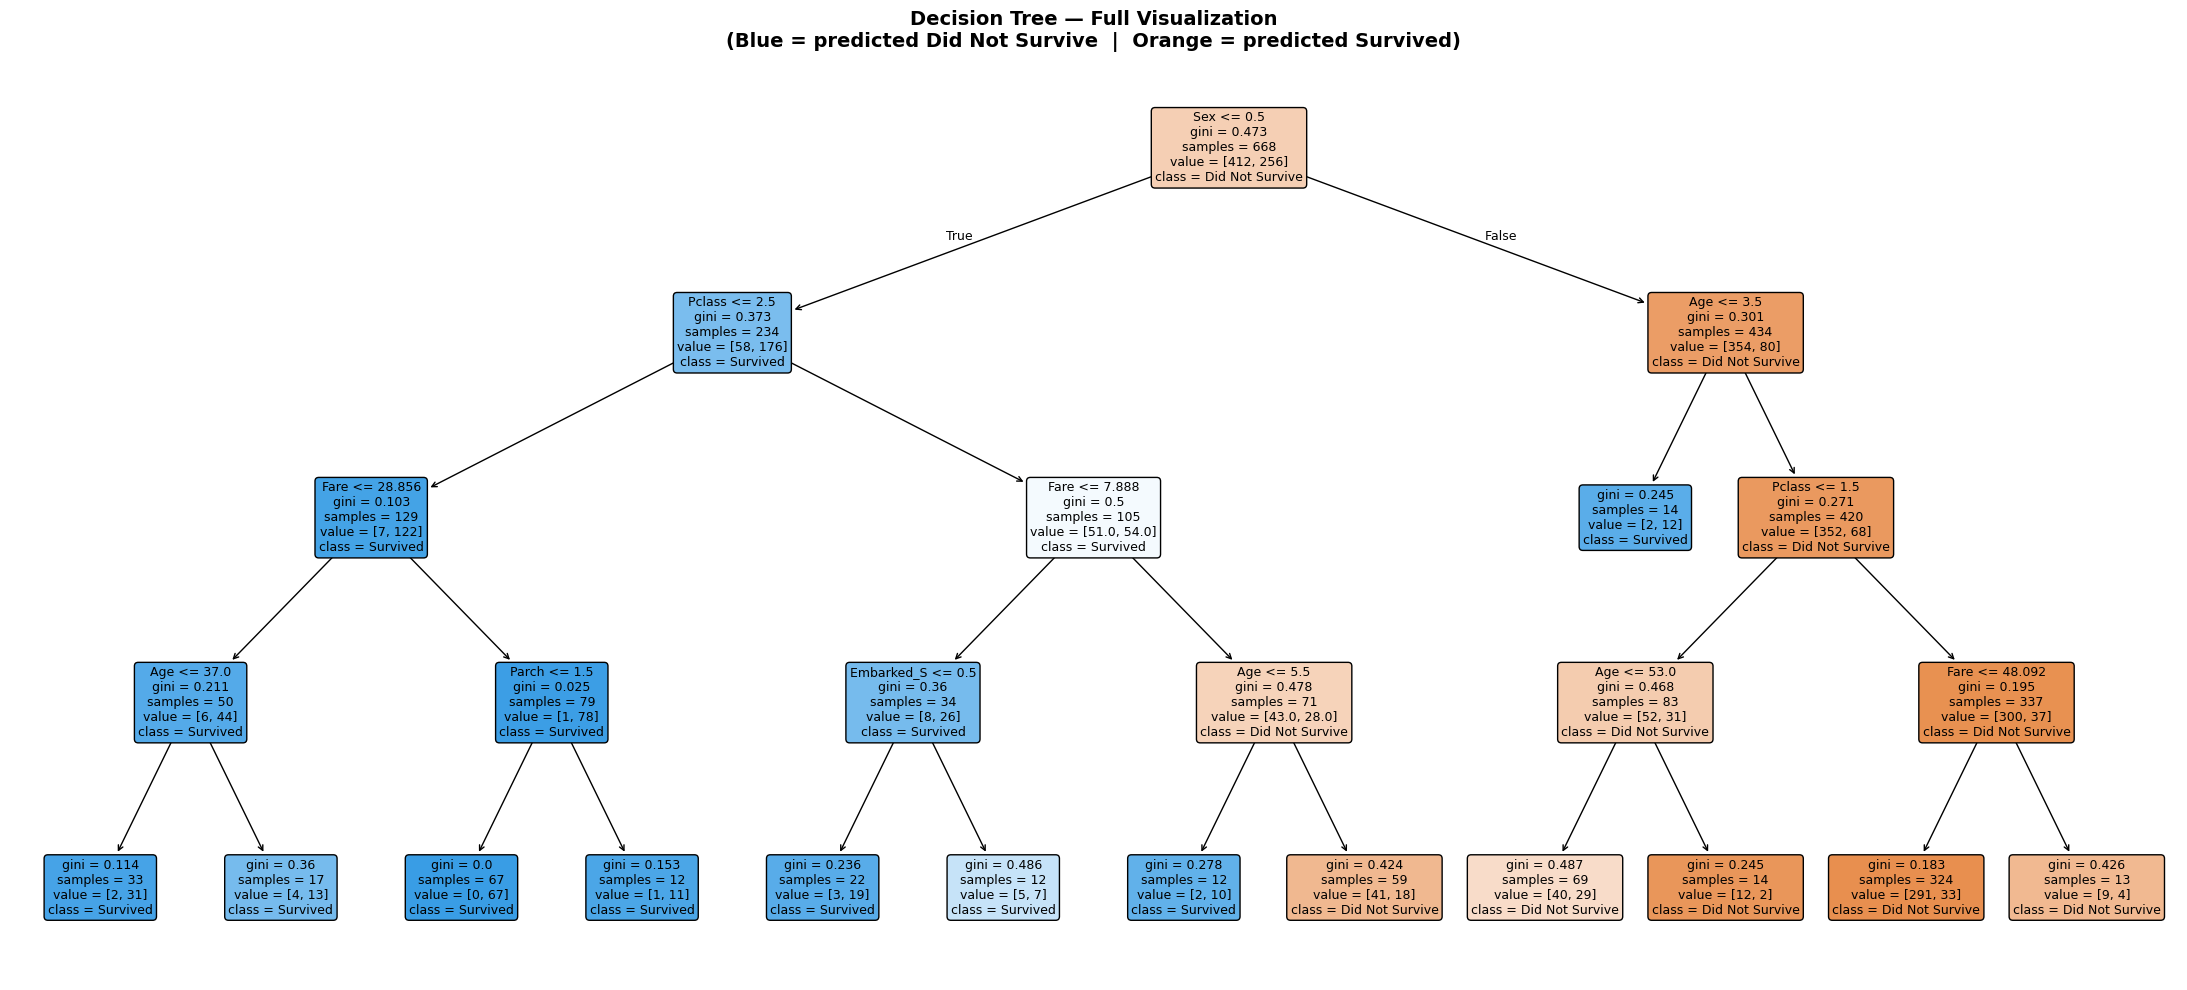

💡 How to read the tree:
   - Each node shows a yes/no question about a feature
   - Left branch = YES (condition is true)
   - Right branch = NO (condition is false)
   - Leaf nodes (bottom) = final predictions
   - 'Sex <= 0.5' means: is the passenger female? (female=0, male=1)


In [140]:
# ── Visualize the Decision Tree ──────────────────────────────────────────────
# This draws the full tree with all questions and decisions
# filled=True colors the nodes: blue = "did not survive", orange = "survived"

plt.figure(figsize=(22, 10))

plot_tree(
    dt,
    feature_names=X_train.columns,          # show actual feature names
    class_names=['Did Not Survive', 'Survived'],  # show class names
    filled=True,     # color nodes by predicted class
    rounded=True,    # rounded rectangle corners (easier to read)
    fontsize=9       # font size for the text inside nodes
)

plt.title(
    'Decision Tree — Full Visualization\n'
    '(Blue = predicted Did Not Survive  |  Orange = predicted Survived)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("💡 How to read the tree:")
print("   - Each node shows a yes/no question about a feature")
print("   - Left branch = YES (condition is true)")
print("   - Right branch = NO (condition is false)")
print("   - Leaf nodes (bottom) = final predictions")
print("   - 'Sex <= 0.5' means: is the passenger female? (female=0, male=1)")

---
## 5.3 — Model 3: Random Forest

**How does Random Forest work?**

Random Forest is an **ensemble method** — it builds **many Decision Trees** and combines their predictions.

Instead of trusting one tree (which might overfit), Random Forest builds **50 different trees**,
each trained on a slightly different random sample of the data.
Then it takes a **majority vote** across all trees.

**Visual example with 3 trees:**

```
Training Data (668 passengers)
         ↓
 Random Sample 1   Random Sample 2   Random Sample 3
      ↓                  ↓                  ↓
    Tree 1             Tree 2             Tree 3
  → Survived         → Not Survived     → Survived

           MAJORITY VOTE:  2 vs 1
           FINAL ANSWER: ✅ Survived
```

**Why is this better than one Decision Tree?**

- One tree might overfit specific patterns in training data
- 50 diverse trees average out the noise
- Result: more stable and accurate predictions

**Two sources of randomness that create diverse trees:**
1. **Bootstrap sampling** — each tree sees a slightly different random subset of rows
2. **Random feature selection** — at each split, only a random subset of features is considered

> 💡 This combination is called **"bagging"** (Bootstrap + Aggregating).


In [141]:
# ── Create the Random Forest model ───────────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=100,     # build 100 different decision trees
    # more trees = more stable predictions, but slower training
    # 100 is a good balance for most problems

    max_depth=5,          # each individual tree can be at most 5 levels deep
    # keeping trees shallow prevents any single tree from overfitting

    min_samples_leaf=8,   # each leaf needs at least 8 passengers
    # this prevents very specific rules that only apply to 1-2 passengers

    random_state=42       # reproducibility
)

# ── Train the model ───────────────────────────────────────────────────────────
# .fit() builds ALL 100 trees internally
# Each tree gets a random sample of rows and considers random feature subsets
# Random Forest also works on UNSCALED data (it's tree-based)

rf.fit(X_train, y_train)

# ── Make predictions ──────────────────────────────────────────────────────────
# .predict() runs each test passenger through ALL 100 trees
# then takes the majority vote (if 60+ trees say "survived", predict survived)
y_pred_rf = rf.predict(X_test)

print("✅ Random Forest trained!")
print(f"   Number of trees built: {rf.n_estimators}")
print(f"   Features available:    {X_train.shape[1]}")
print(f"   Training samples used: {X_train.shape[0]}")

✅ Random Forest trained!
   Number of trees built: 100
   Features available:    8
   Training samples used: 668


  🌲 Random Forest — Classification Report
                 precision    recall  f1-score   support

Did Not Survive     0.8039    0.8978    0.8483       137
       Survived     0.8000    0.6512    0.7179        86

       accuracy                         0.8027       223
      macro avg     0.8020    0.7745    0.7831       223
   weighted avg     0.8024    0.8027    0.7980       223



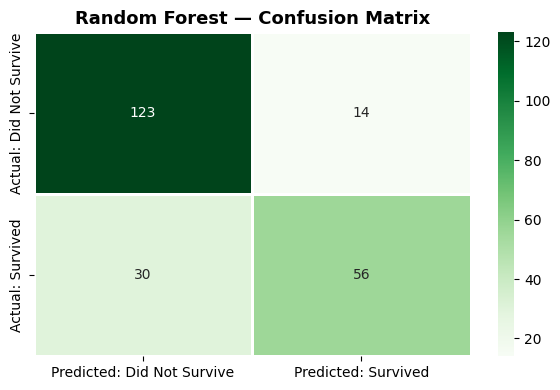

✅ True Negatives  (TN): 123
❌ False Positives (FP): 14
❌ False Negatives (FN): 30
✅ True Positives  (TP): 56


In [142]:
# ── Print the Classification Report ─────────────────────────────────────────

print("=" * 55)
print("  🌲 Random Forest — Classification Report")
print("=" * 55)

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Did Not Survive', 'Survived'],
    digits=4
))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted: Did Not Survive', 'Predicted: Survived'],
    yticklabels=['Actual: Did Not Survive', 'Actual: Survived'],
    linewidths=1,
    linecolor='white'
)
plt.title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"✅ True Negatives  (TN): {tn}")
print(f"❌ False Positives (FP): {fp}")
print(f"❌ False Negatives (FN): {fn}")
print(f"✅ True Positives  (TP): {tp}")

### 🔍 Feature Importance — What did Random Forest learn?

A great bonus of Random Forest is **feature importance**.

It tells us: **which features were most useful** for making accurate predictions?
The model tracks how much each feature reduces uncertainty (Gini impurity) across all 100 trees.

> 💡 This is very valuable — it tells us which columns actually mattered,
> and helps guide future feature engineering.


Feature Importance Scores (sum = 1.0):
----------------------------------------
  Sex             0.4844  ████████████████████████
  Fare            0.1952  █████████
  Pclass          0.1465  ███████
  Age             0.0889  ████
  Parch           0.0302  █
  SibSp           0.0246  █
  Embarked_S      0.0187  
  Embarked_Q      0.0115  

✅ Top feature: 'Sex' accounts for 48.4% of decisions


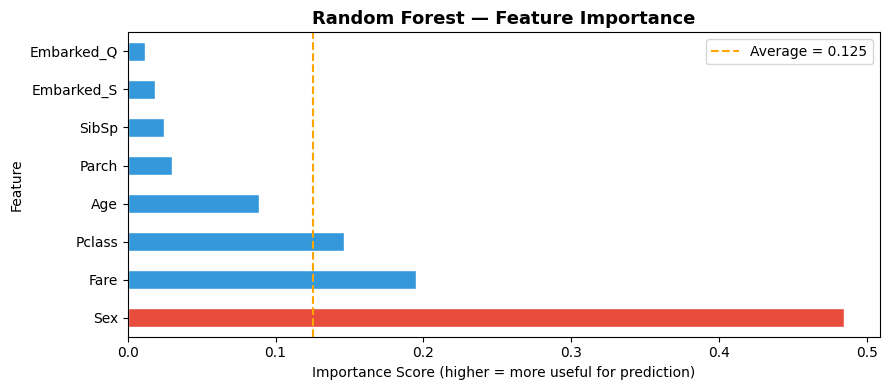

💡 Interpretation:
   - Features above the orange line are MORE important than average
   - Features below the orange line contribute less
   - Consider removing very low-importance features in future experiments


In [143]:
# ── Feature Importance ───────────────────────────────────────────────────────
# rf.feature_importances_ gives a score for each feature
# Higher score = the model relied on this feature more for its decisions
# All scores add up to 1.0 (100%)

# Create a sorted Series for easy viewing
importances = pd.Series(
    rf.feature_importances_,   # the importance scores from the Random Forest
    index=X_train.columns      # label them with the feature names
).sort_values(ascending=False) # sort from most to least important

print("Feature Importance Scores (sum = 1.0):")
print("-" * 40)
for feature, score in importances.items():
    bar = "█" * int(score * 50)  # visual bar proportional to importance
    print(f"  {feature:<15} {score:.4f}  {bar}")

print()
print(f"✅ Top feature: '{importances.index[0]}' accounts for {importances.iloc[0]*100:.1f}% of decisions")

# ── Plot the feature importances ─────────────────────────────────────────────
plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(importances))]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (higher = more useful for prediction)')
plt.ylabel('Feature')
plt.axvline(x=importances.mean(), color='orange', linestyle='--',
            label=f'Average = {importances.mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("   - Features above the orange line are MORE important than average")
print("   - Features below the orange line contribute less")
print("   - Consider removing very low-importance features in future experiments")

---
## 5.4 — Model 4: XGBoost Classifier

**How does XGBoost work?**

XGBoost (Extreme Gradient Boosting) uses **boosting** — a very different idea from Random Forest.

Instead of building trees in **parallel** (independently), XGBoost builds them **sequentially**:
- Tree 1 makes predictions → identifies which passengers it got wrong
- Tree 2 focuses on fixing those mistakes
- Tree 3 focuses on fixing what Trees 1+2 still got wrong
- ...this continues for 100 trees

**Visualized:**

```
Tree 1: 89 errors  ──→  Tree 2 focuses on those 89
Tree 2: 52 errors  ──→  Tree 3 focuses on those 52
Tree 3: 34 errors  ──→  Tree 4 focuses on those 34
...
Tree 100: ~18 errors remaining

FINAL = weighted combination of ALL 100 trees
```

**Key parameters:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_estimators=100` | 100 trees | How many trees to build sequentially |
| `max_depth=3` | 3 levels | Each tree is very shallow (just a few questions) |
| `learning_rate=0.1` | 0.1 | How aggressively each tree corrects errors (lower = more careful) |
| `random_state=42` | 42 | Reproducibility |

> 💡 XGBoost is often the **top-performing algorithm** on tabular (table) data.
> It's won many data science competitions and is widely used in industry.


In [144]:
# ── Create the XGBoost model ──────────────────────────────────────────────────

xgb = XGBClassifier(
    n_estimators=100,    # build 100 sequential trees
    # each tree corrects the errors of the previous ones

    max_depth=3,         # each tree is very shallow (only 3 levels)
    # shallow trees are called "weak learners" — individually not great,
    # but combined they become very powerful

    learning_rate=0.1,   # how much each tree corrects errors
    # 0.1 means each tree fixes 10% of remaining errors
    # lower = more careful, more stable (but slower)
    # higher = faster but can overshoot and become unstable

    random_state=42,     # reproducibility
    eval_metric='logloss',    # internal metric used during training
    verbosity=0          # suppress output during training
)

# ── Train the model ───────────────────────────────────────────────────────────
# .fit() builds all 100 trees sequentially
# Each tree analyzes the RESIDUALS (errors) from the previous trees
# XGBoost also works on UNSCALED data (tree-based)

xgb.fit(X_train, y_train)

# ── Make predictions ──────────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)

print("✅ XGBoost trained!")
print(f"   Trees built:          {xgb.n_estimators}")
print(f"   Max depth per tree:   {xgb.max_depth}")
print(f"   Learning rate:        {xgb.learning_rate}")

✅ XGBoost trained!
   Trees built:          100
   Max depth per tree:   3
   Learning rate:        0.1


  ⚡ XGBoost — Classification Report
                 precision    recall  f1-score   support

Did Not Survive     0.7702    0.9051    0.8322       137
       Survived     0.7903    0.5698    0.6622        86

       accuracy                         0.7758       223
      macro avg     0.7803    0.7374    0.7472       223
   weighted avg     0.7780    0.7758    0.7666       223



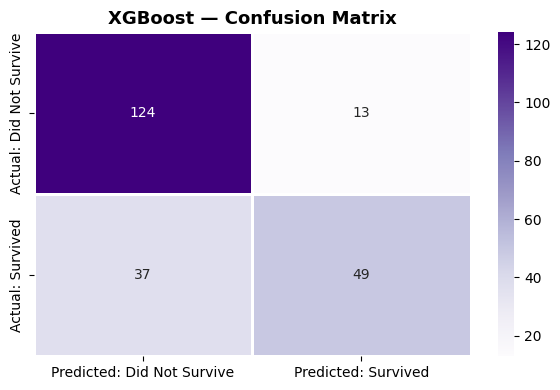

✅ True Negatives  (TN): 124
❌ False Positives (FP): 13
❌ False Negatives (FN): 37
✅ True Positives  (TP): 49


In [145]:
# ── Print the Classification Report ─────────────────────────────────────────

print("=" * 55)
print("  ⚡ XGBoost — Classification Report")
print("=" * 55)

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Did Not Survive', 'Survived'],
    digits=4
))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Predicted: Did Not Survive', 'Predicted: Survived'],
    yticklabels=['Actual: Did Not Survive', 'Actual: Survived'],
    linewidths=1,
    linecolor='white'
)
plt.title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"✅ True Negatives  (TN): {tn}")
print(f"❌ False Positives (FP): {fp}")
print(f"❌ False Negatives (FN): {fn}")
print(f"✅ True Positives  (TP): {tp}")

---
# 📊 Step 6: Model Comparison

Let's put all 4 models side-by-side and see which performed best.

We'll look at 4 metrics for each model:
- **Accuracy** — overall correct predictions
- **Precision** — how precise when predicting "Survived"
- **Recall** — how well we catch actual survivors
- **F1-Score** — the balanced metric (our main comparator)


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Gather all predictions ────────────────────────────────────────────────────
all_models = {
    'KNN (K=5)':      y_pred_knn,
    'Decision Tree':  y_pred_dt,
    'Random Forest':  y_pred_rf,
    'XGBoost':        y_pred_xgb,
}

# ── Compute metrics for each model ───────────────────────────────────────────
# We loop through each model, compare its predictions to the real answers (y_test)
# and store all 4 metrics in a list of dictionaries

results = []
for model_name, y_pred in all_models.items():
    results.append({
        'Model':     model_name,
        'Accuracy':  round(accuracy_score (y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score   (y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score       (y_test, y_pred, zero_division=0), 4),
    })

# ── Build a comparison table ──────────────────────────────────────────────────
results_df = pd.DataFrame(results)           # convert list of dicts → DataFrame
results_df = results_df.set_index('Model')   # use model name as the row label
results_df = results_df.sort_values('F1-Score', ascending=False)  # best first

print("=" * 65)
print("          📊 Model Comparison — All Metrics")
print("=" * 65)
print(results_df.to_string())
print()

# ── Identify the winner ───────────────────────────────────────────────────────
best_model = results_df['F1-Score'].idxmax()  # name of model with highest F1
best_score = results_df['F1-Score'].max()
print(f"🏆 Best model by F1-Score: {best_model}  ({best_score:.4f})")

          📊 Model Comparison — All Metrics
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest    0.8027     0.8000  0.6512    0.7179
KNN (K=5)        0.7937     0.7632  0.6744    0.7160
XGBoost          0.7758     0.7903  0.5698    0.6622
Decision Tree    0.7668     0.8036  0.5233    0.6338

🏆 Best model by F1-Score: Random Forest  (0.7179)


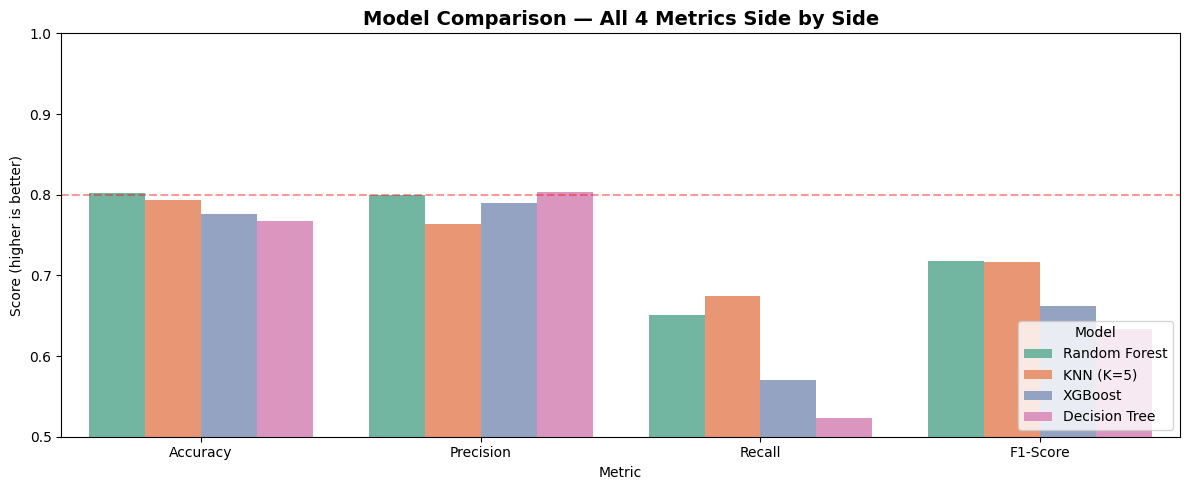


💡 Reading this chart:
   - Higher bar = better performance on that metric
   - F1-Score is the most balanced metric to compare models
   - The red dashed line marks the 80% threshold


In [147]:
# ── Visualize the comparison ─────────────────────────────────────────────────
# We melt the table so we can plot each metric as a grouped bar

results_plot = results_df.reset_index()
results_melted = results_plot.melt(
    id_vars='Model',       # keep Model column as the group identifier
    var_name='Metric',     # the 4 metric names become a new column called 'Metric'
    value_name='Score'     # the values go into a column called 'Score'
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=results_melted,
    x='Metric',            # x-axis: which metric
    y='Score',             # y-axis: the score value
    hue='Model',           # color by model name
    palette='Set2'         # a clean, distinct color set
)
plt.title('Model Comparison — All 4 Metrics Side by Side', fontsize=14, fontweight='bold')
plt.ylabel('Score (higher is better)')
plt.xlabel('Metric')
plt.ylim(0.5, 1.0)         # zoom in: we know scores are between 50-100%
plt.legend(title='Model', loc='lower right')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, label='80% reference line')
plt.tight_layout()
plt.show()

print()
print("💡 Reading this chart:")
print("   - Higher bar = better performance on that metric")
print("   - F1-Score is the most balanced metric to compare models")
print("   - The red dashed line marks the 80% threshold")

---
# 🎓 Summary & Key Takeaways

## ✅ What We Accomplished

| Step | What we did | Key lesson |
|------|------------|------------|
| **Feature Selection** | Defined X (features) and y (target) | Always separate inputs from outputs |
| **Train/Test Split** | 75% train, 25% test with `stratify=y` | Never evaluate on data the model has seen |
| **Feature Scaling** | `fit_transform` on train, `transform` on test | Fit scaler only on training data — no leakage |
| **KNN** | K=5 nearest neighbors, needs scaled data | Simple, intuitive, sensitive to scale |
| **Decision Tree** | Yes/no questions, depth=4, visualizable | Interpretable, no scaling needed |
| **Random Forest** | 100 trees, majority vote, feature importance | More stable than single tree |
| **XGBoost** | 100 sequential trees, corrects errors | Often best accuracy on tabular data |
| **Evaluation** | Accuracy, Precision, Recall, F1 + confusion matrix | F1 is most balanced for this dataset |

---

## 🧠 Key Concepts to Remember

1. **X and y** — X is the inputs (features), y is the output (target we predict)
2. **Train/Test Split** — always evaluate on data the model has NEVER seen
3. **Data Leakage** — NEVER fit the scaler on test data, only on training data
4. **Scaling** — required for KNN (distance-based); not needed for tree-based models
5. **Confusion Matrix** — shows exactly which types of errors the model makes
6. **F1-Score** — the best single metric when classes are slightly imbalanced
7. **Feature Importance** — tells us which features the model actually used

---

## 🚀 What to Explore Next

- **Cross-validation** — instead of one train/test split, split 5 ways and average results
- **Hyperparameter tuning** — use `GridSearchCV` to automatically find the best `max_depth`, `K`, etc.
- **Feature engineering** — extract the passenger's title (Mr., Mrs., Miss.) from the Name column
- **Logistic Regression** — a simple but powerful baseline model worth trying first


---
# 💾 Step 7: Export Models for the Interactive Web Demo

In this final step, we export our 4 trained models so they can be loaded
by the standalone HTML demo app.

We export:
- The **4 trained models** (KNN, Decision Tree, Random Forest, XGBoost)
- The **StandardScaler** (needed to scale inputs before KNN predictions)
- A single **`models_export.json`** containing everything the web app needs

> 💡 We use `joblib` for the sklearn models and XGBoost's native `save_model()`.
> Then we bundle the scaler parameters and model metadata into a single JSON
> so the browser can call the models via a lightweight Python micro-server.


In [ ]:
# Install required packages for export
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'joblib', 'flask', 'flask-cors'], check=True, capture_output=True)

import joblib
import json
import numpy as np
import os

print('✅ Export packages ready.')

In [ ]:
# ── Create output directory ──────────────────────────────────────────────
export_dir = 'titanic_model_export'
os.makedirs(export_dir, exist_ok=True)

# ── Save all 4 models ─────────────────────────────────────────────────────
joblib.dump(knn, f'{export_dir}/model_knn.pkl')
joblib.dump(dt,  f'{export_dir}/model_dt.pkl')
joblib.dump(rf,  f'{export_dir}/model_rf.pkl')
joblib.dump(xgb, f'{export_dir}/model_xgb.pkl')

# ── Save the scaler (needed for KNN) ──────────────────────────────────────
joblib.dump(scaler, f'{export_dir}/scaler.pkl')

# ── Save scaler parameters as JSON too (for inspection) ──────────────────
scaler_params = {
    'mean':  scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'feature_names': X.columns.tolist()
}
with open(f'{export_dir}/scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)

print('✅ Models saved:')
for fname in sorted(os.listdir(export_dir)):
    size = os.path.getsize(f'{export_dir}/{fname}')
    print(f'   {fname:<30} ({size:,} bytes)')

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ── Build model metadata for the web app ─────────────────────────────────
model_meta = {
    'feature_names': X.columns.tolist(),
    'feature_order': X.columns.tolist(),
    'models': [
        {
            'id':          'knn',
            'name':        'KNN (K=5)',
            'file':        'model_knn.pkl',
            'needs_scale': True,
            'accuracy':    round(accuracy_score(y_test,  y_pred_knn),  4),
            'f1':          round(f1_score(y_test,        y_pred_knn,  zero_division=0), 4),
            'precision':   round(precision_score(y_test, y_pred_knn,  zero_division=0), 4),
            'recall':      round(recall_score(y_test,    y_pred_knn,  zero_division=0), 4),
            'description': 'Finds the 5 most similar training passengers and takes a majority vote.'
        },
        {
            'id':          'dt',
            'name':        'Decision Tree',
            'file':        'model_dt.pkl',
            'needs_scale': False,
            'accuracy':    round(accuracy_score(y_test,  y_pred_dt),   4),
            'f1':          round(f1_score(y_test,        y_pred_dt,   zero_division=0), 4),
            'precision':   round(precision_score(y_test, y_pred_dt,   zero_division=0), 4),
            'recall':      round(recall_score(y_test,    y_pred_dt,   zero_division=0), 4),
            'description': 'Asks a series of yes/no questions (max depth 4) to reach a decision.'
        },
        {
            'id':          'rf',
            'name':        'Random Forest',
            'file':        'model_rf.pkl',
            'needs_scale': False,
            'accuracy':    round(accuracy_score(y_test,  y_pred_rf),   4),
            'f1':          round(f1_score(y_test,        y_pred_rf,   zero_division=0), 4),
            'precision':   round(precision_score(y_test, y_pred_rf,   zero_division=0), 4),
            'recall':      round(recall_score(y_test,    y_pred_rf,   zero_division=0), 4),
            'description': 'Builds 100 different trees and takes a majority vote across all of them.'
        },
        {
            'id':          'xgb',
            'name':        'XGBoost',
            'file':        'model_xgb.pkl',
            'needs_scale': False,
            'accuracy':    round(accuracy_score(y_test,  y_pred_xgb),  4),
            'f1':          round(f1_score(y_test,        y_pred_xgb,  zero_division=0), 4),
            'precision':   round(precision_score(y_test, y_pred_xgb,  zero_division=0), 4),
            'recall':      round(recall_score(y_test,    y_pred_xgb,  zero_division=0), 4),
            'description': 'Builds 100 trees sequentially, each one correcting the previous errors.'
        },
    ]
}

with open(f'{export_dir}/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('✅ Model metadata saved to model_meta.json')
print()
print('Model performance summary:')
for m in model_meta['models']:
    print(f"   {m['name']:<18}  acc={m['accuracy']:.4f}  f1={m['f1']:.4f}")

---
## 🚀 How to Use the Demo App

Your export is ready in the `titanic_model_export/` folder.

**Step 1 — Start the Flask server:**
```bash
pip install flask flask-cors
python titanic_model_export/server.py
```
You should see:
```
🚢  Titanic Model Server running at http://localhost:5050
```

**Step 2 — Open the demo in your browser:**
Open `titanic_demo.html` directly in Chrome or Firefox.
The page auto-connects to the server and loads model accuracy scores.

**Step 3 — Enter passenger details and click Predict.**
All 4 models run in parallel and show:
- ✅ Survived / ❌ Did Not Survive verdict
- Confidence % and probability bars for each class

---
### 📁 Files Created

| File | Description |
|------|-------------|
| `titanic_model_export/model_knn.pkl` | Trained KNN model |
| `titanic_model_export/model_dt.pkl` | Trained Decision Tree |
| `titanic_model_export/model_rf.pkl` | Trained Random Forest |
| `titanic_model_export/model_xgb.pkl` | Trained XGBoost |
| `titanic_model_export/scaler.pkl` | StandardScaler (for KNN) |
| `titanic_model_export/scaler_params.json` | Scaler mean/std as JSON |
| `titanic_model_export/model_meta.json` | Model metadata + accuracy scores |
| `titanic_model_export/server.py` | Flask API server |
| `titanic_demo.html` | Interactive demo (open in browser) |
